# QRC Lyapunov Companio Notebook

This notebook generates chaotic benchmarks (Lorenz-96m Mackey-Glass) and computes finite-time Lyapunov exponents (FLEs).
It also provides scaffolding for integrating Lyapunov analysis into a Quantum Reservoir COmputing (QRC) workflow via Jacobian-vector products.

**References**: Jaeger (2001) , Galtier & Wainrib (2015), Dieci et al. (1997), Ginelli et al.(2007), Oseledets(2011) , Fujii & Nakajima (2017)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.set_printoptions(suppress=True, linewidth=120)

## Lorenz-96 System (RK4 integrator)
Standard chaotic testbed with cyclic advection and forcing $F=8$

In [2]:
def lorenz96(x, F=8.0):
    # x: shape (K,) with cyclic indexing
    K = x.size
    xp1 = np.roll(x, -1)
    xm1 = np.roll(x,1)
    xm2 = np.roll(x,2)
    return (xp1 - xm2) * xm1 -x + F

def rk4_step(f, x, dt, **kwargs):
    k1 = f(x, **kwargs)
    k2 = f(x + 0.5*dt*k1, **kwargs)
    k3 = f(x + 0.5*dt*k2, **kwargs)
    k4 = f(x + dt*k3, **kwargs)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def simulate_l96(K=20, F=8.0, dt=0.01, steps=3000, x0=None, burn=1000):
    x=F*np.ones(K) if x0 is None else x0.copy()
    x[0] += 0.01
    traj = []
    for t in range(steps + burn):
        x = rk4_step(lorenz96, x, dt, F=F)
        if t>= burn:
            traj.append(x.copy())
    return np.array(traj)

traj = simulate_l96(K=20, F=8.0, dt=0.01, steps=5000)
traj.shape
    

(5000, 20)

### Jacobian of Lorenz-96
For $x\in\mathbb{R}^k$, the Jacobian $J$ has components:
$J_{i,i} = -1$, $J_{i,i-1} = x_{i+1} - x_{i-2}$, $J_{i,i+1} = x_{i-1}$, $J_{i,i-2} = -x_{i-1}$ (with cyclic indices).

In [3]:
def jacobian_l96(x):
    K =x.size
    J=np.zeros((K, K))
    for i in range(K):
        im1 = (i -1) % K
        im2 = (i -2) % K
        ip1 = (i -1) % K
        #entries
        J[i, i] = -1.0
        J[i, im1] = x[ip1] - x[im2]
        J[i, ip1] = x[im1]
        J[i, im2] = -x[im1]
    return J

# Test on a sample state
Jtest = jacobian_l96(traj[0])
Jtest.shape, np.linalg.norm(Jtest)

((20, 20), 29.23411702065214)

### QR-based Largest Lyapunov Exponent (finite-time)
We approximate the largest LE by iteratively multiplying tangent vectors by the Jacobian along the trajectory and re-orthonormalizing (Benetting/QR).

Estimated largest LE (per time unit):2.04928699869034


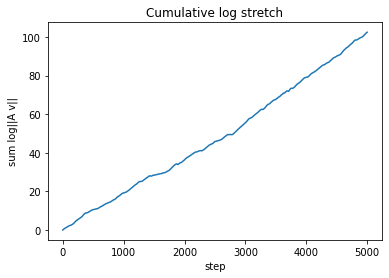

In [6]:
def largest_le_qr(traj, dt=0.01, stride=1):
    # traj: (T,K) states sampled every dt
    T, K = traj.shape
    v = np.random.randn(K)
    v /= np.linalg.norm(v)
    logs = []
    for t in range(0,T,stride):
        J = jacobian_l96(traj[t])
        # Tangent map over one integration step ~ I + dt*J (Euler Linearization)
        A = np.eye(K) + dt * J
        v = A @ v
        ln = np.linalg.norm(v)
        v /= ln
        logs.append(np.log(ln))
    lam = np.sum(logs) / (len(logs) * dt * stride)
    return lam, np.array(logs)

lam, logs = largest_le_qr(traj, dt=0.01, stride=1)
print(f"Estimated largest LE (per time unit):{lam}")
plt.figure(); plt.plot(np.cumsum(logs)); plt.title('Cumulative log stretch');plt.xlabel('step');plt.ylabel('sum log||A v||');
plt.show()

## Mackey-Glass (Delay) Generator and Rosenstein MLE
We implement a simple Euler-like dealy solver with a ring buffer and estiamte the largest Lyapunov exponent using the Rosenstein algorithm on an embedded attractor

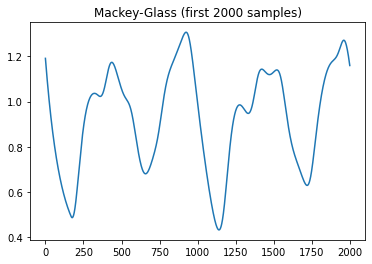

In [9]:
def mackey_glass(T=20000, dt=0.1, tau=17.0, beta=0.2, gamma=0.1, n=10, x0=1.2):
    # dx/dt = beta * x(t-tau) / (1 + x(t - tau)^n) - gamma * x(t)
    delay_steps = int(round(tau/dt))
    buf = np.ones(delay_steps) * x0
    x = x0
    series = []
    for k in range(T):
        x_tau = buf[k % delay_steps]
        dx = beta * x_tau / (1.0 + x_tau**n) - gamma * x
        x = x + dt * dx
        buf[k % delay_steps] = x
        series.append(x)
    return np.array(series)

mg = mackey_glass(T=50000, dt=0.1)
plt.figure(); plt.plot(mg[:2000]); plt.title('Mackey-Glass (first 2000 samples)');
plt.show()
    

Rosenstein MLE (per sample): 0.008421410163140743


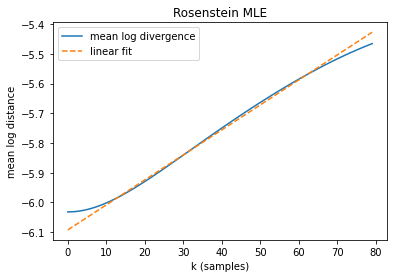

In [15]:
def delay_embed(x, m=3, tau=10):
    N = len(x) - (m-1)*tau
    X = np.zeros((N,m))
    for i in range(m):
        X[:,i] = x[i*tau:i*tau + N]
    return X

def rosenstein_mle(x, m=6, tau=15, mean_drift=50, theiler=100):
    # Track average divergence of nearest neighbours
    X = delay_embed(x, m=m, tau=tau)
    N = X.shape[0]
    # nearest neighbour indices with Theiler window
    nn = np.zeros(N, dtype=int)
    for i in range(N):
        d = np.linalg.norm(X - X[i], axis=1)
        d[max(0, i-theiler):min(N, i+theiler+1)] = np.inf
        nn[i] = np.argmin(d)
    # divergence curves
    L = mean_drift
    div = np.zeros(L)
    count = np.zeros(L)
    for i in range(N - L):
        j = nn[i]
        for k in range(L):
            if i+k < N and j+k < N:
                dist = np.linalg.norm(X[i+k] - X[j+k])
                if dist > 0:
                    div[k] += np.log(dist)
                    count[k] += 1
    valid = count > 0
    t = np.arange(L)[valid]
    y = div[valid]/count[valid]
    # fit on a middle region to estimate slope (MLE)
    lo, hi = max(5, int(0.1*L)), int(0.5*L)
    coeffs = np.polyfit(t[lo:hi],y[lo:hi], 1)
    mle = coeffs[0] # per sample
    return mle, t, y

mle, t, y = rosenstein_mle(mg, m=6, tau=15, mean_drift=80, theiler=200)
print('Rosenstein MLE (per sample):', mle)
plt.figure(); plt.plot(t, y, label='mean log divergence');
plt.plot(t, np.poly1d(np.polyfit(t[8:40], y[8:40], 1))(t), '--', label='linear fit');
plt.legend(); plt.xlabel('k (samples)'); plt.ylabel('mean log distance');
plt.title('Rosenstein MLE');plt.show()
    

## Scaffold: Integrating a QRC Jacobian
To incorporate Lyapunov analysis for a QRC reservoir, expose a function `jvp(x_t, u_t, v)` that returns $J_t v$ (Jacobian-vector product), then replace the explicit Jacobian in the QR loop with this callback.

ingore this and below cell. It was developed earlier but as you see is incomplete. FOcus on the next cell

In [17]:
# class QRCInterface:
#     def __init__(self): 
#         pass # initialize reservoir, encoding, etc.
#     def step(self, x_t, u_t):
#         # return next state x_{t+1}
#         raise NotImplementedError
#     def jvp(self, x_t, u_t, v):
#         # return Jacobian-vector product J_t v (e.g., via MPO application)
#         raise NotImplementedError
        
# def largest_le_qr_jvp(states, inputs, jvp_cb):
#     # states[t] = x_t, inputs[t] = u_t: v is unit vector
#     k = states[0].size
#     v = np.random.randn(K); v /= np.linalg.norm(v)
#     logs = []
#     for t in range(len(states)):
#         w = jvp_cb(states[t], inputs[t], v)
#         ln = np.linalg.norm(w)
#         v = w/ln if ln>0 else v
#         logs.append(np.log(max(ln, 1e-12)))
#     return np.mean(logs), np.array(logs)

# QRC JVP Integration - End-to-End 

This section provides: QRCInterface, larges LE(JVP), top-q LEs (JVP), CLVs , a demo run and forecasting.

In [25]:
import numpy as np

class QRCInterface:
    """
    Minimal QRC interface for demonstration. Replace the evolution/JVP with you quantum backend or MPO-MPS contractions.
    """
    def __init__(self, K=128, seed=0, input_scale=0.5, leak=1.0): 
        rng = np.random.default_rng(seed) 
        self.K = K
        self.leak = leak
        self.W = rng.standard_normal((K,K)) / np.sqrt(K)
        self.B = rng.standard_normal((K,)) * input_scale
        self.state = np.zeros(K)
        
    def encode(self, u_t):
        return float(u_t)
    
    def nonlinearity(self, z):
        return np.tanh(z)
        
    def step(self, x_t, u_t):
        u = self.encode(u_t)
        pre = self.W @ x_t + self.B * u
        x_next = (1 - self.leak) * x_t + self.leak * self.nonlinearity(pre)
        self.state = x_next
        return x_next
        
    def jvp(self, x_t, u_t, v):
        u = self.encode(u_t)
        pre = self.W @ x_t + self.B * u
        dphi = 1.0 - np.tanh(pre)**2
        w_lin = self.W @ v
        w = (1 - self.leak) * v + self.leak * (dphi * w_lin)
        return w
        


### Largest LE via JVP

In [30]:
def largest_le_qr_jvp(states, inputs, qrc, dt=1.0):
    # states[t] = x_t, inputs[t] = u_t: v is unit vector
    K = states[0].size
    rng = np.random.default_rng(0)
    v = rng.standard_normal(K);
    v /= np.linalg.norm(v) + 1e-12
    logs = []
    for t in range(len(states)-1):
        w = qrc.jvp(states[t], inputs[t], v)
        ln = np.linalg.norm(w) + 1e-12
        v = w/ln
        logs.append(np.log(ln))
    lam = np.sum(logs) / (len(logs) * dt)
    return lam, np.array(logs)

### Top-q LEs via JVP (QR)

In [27]:
def multi_le_qr_jvp(states, inputs, qrc, q=5, dt=1.0):
    T, K = states.shape
    Q, _ = np.linalg.qr(np.random.default_rng(42).standard_normal((K, q)))
    sums = np.zeros(q)
    logR = []
    for t in range(T-1):
        Y = np.zeros_like(Q)
        for i in range (q):
            Y[:, i] = qrc.jvp(states[t], inputs[t], Q[:, i])
        Q, R = np.linalg.qr(Y)
        diagR = np.abs(np.diag(R)) + 1e-12
        sums += np.log(diagR)
        logR.append(np.log(diagR))
    lambdas = sums / ((T-1) * dt)
    return lambdas, np.array(logR)

# Forward store + CLV backward

In [28]:
def forward_qr_jvp_store(states, inputs, qrc, q=5, dt=1.0):
    T, K = states.shape
    Q, _ = np.linalg.qr(np.random.default_rng(7).standard_normal((K, q)))
    Q_list = [Q.copy()]
    R_list = []
    sums = np.zeros(q)
    for t in range(T-1):
        Y = np.zeros_like(Q)
        for i in range(q):
            Y[:, i] = qrc.jvp(states[t], inputs[t], Q[:, i])
        Q, R = np.linalg.qr(Y)
        Q_list.append(Q.copy())
        R_list.append(R.copy())
        sums += np.log(np.abs(np.diag(R)) + 1e-12)
    lambdas = sums / ((T-1) * dt)
    return lambdas, Q_list, R_list

def clv_backward(Q_list, R_list):
    T = len(R_list)
    q = R_list[0].shape[0]
    V_list = [None]*T
    W = np.eye(q)
    for t in range(T-1, -1, -1):
        Rt1 = R_list[t]
        W = np.linalg.solve(Rt1, W)
        V_t = Q_list[t] @ W
        V_list[t] = V_t
    return V_list

# Demo: Simulate QRC, Compute LEs and CLVs

In [31]:
def simulate_qrc(qrc, u_stream, x0=None):
    K = qrc.K
    x = np.zeros(K) if x0 is None else x0.copy()
    states = [x.copy()]
    for u in u_stream:
        x = qrc.step(x, u)
        states.append(x.copy())
    return np.array(states[:-1]), np.array(u_stream)

# Demo run
rng = np.random.default_rng(1)
T_demo = 3000
u_stream = 0.5 * rng.standard_normal(T_demo)
qrc = QRCInterface(K=128, input_scale=0.5, leak=0.6, seed=1)

states, inputs = simulate_qrc(qrc, u_stream)
lam1, logs1 = largest_le_qr_jvp(states, inputs, qrc, dt=1.0)
print(f'Largest LE (JVP): {lam1}')

lams_q, logR = multi_le_qr_jvp(states, inputs, qrc, q=5, dt=1.0)
print(f'Top-5 LEs (JVP): {lams_q}')

lams_store, Q_list, R_list = forward_qr_jvp_store(states, inputs, qrc, q=5, dt=1.0)
V_list = clv_backward(Q_list, R_list)
print('CLV list lenght: {len(V_list)}', 'CLV[0] shape:', V_list[0].shape)

Largest LE (JVP): -0.04651256623621783
Top-5 LEs (JVP): [-0.04691358 -0.08666703 -0.10948027 -0.11095627 -0.11996713]
CLV list lenght: {len(V_list)} CLV[0] shape: (128, 5)


# Forecasting with ridge readout on QRC states

Validation NRMSE: 0.6777, lambda*: 1.0e-02
Test NRMSE (one-step): 0.6987
Test NRMSE (multi-step rollout): 0.6987


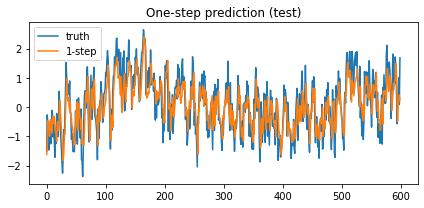

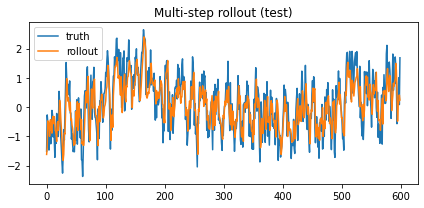

In [34]:
import matplotlib.pyplot as plt

X = states
y = X[:, 0]
y = (y - y.mean()) / (y.std() + 1e-12)

T = len(y)
T_train = int(0.6*T);
T_valid = int(0.2*T)
T_test = T - T_train - T_valid

y_train = y[:T_train]
y_valid = y[T_train:T_train+T_valid]
y_test = y[T_train+T_valid:]

# Align features for one-step prediction: X_t -> y_{t+1}

Xtr = X[:T_train-1]
Xva = X[T_train:T_train+T_valid-1]
Xte = X[T_train+T_valid:T-1]

tgt_tr = y_train[1:];
tgt_va = y_valid[1:]
tgt_te = y_test[1:]

def add_bias(A):
    return np.hstack([A, np.ones((A.shape[0],1))])

Xtr_b, Xva_b, Xte_b = add_bias(Xtr), add_bias(Xva), add_bias(Xte)

lam_grid = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
best = None
for lam in lam_grid:
    XtX = Xtr_b.T @ Xtr_b
    reg = lam * np.eye(XtX.shape[0])
    Wout = (tgt_tr @ Xtr_b) @ np.linalg.inv(XtX + reg)
    yhat_va = Xva_b @ Wout.T
    nrmse_va = Xva_b @ Wout.T
    nrmse_va = np.linalg.norm(yhat_va - tgt_va) / (np.linalg.norm(tgt_va) + 1e-12)
    if (best is None) or (nrmse_va < best[0]):
        best = (nrmse_va, lam, Wout)
        
nrmse_va, lam_star,Wout = best
print(f'Validation NRMSE: {nrmse_va:.4f}, lambda*: {lam_star:.1e}')

yhat_te_1 = Xte_b @ Wout.T
nrmse_te_1 = np.linalg.norm(yhat_te_1 - tgt_te) / (np.linalg.norm(tgt_te) + 1e-12)
print(f'Test NRMSE (one-step): {nrmse_te_1:.4f}')

H = len(tgt_te)
roll = []
u_curr = y[T_train+T_valid-1]
for h in range(H):
    x_b = np.hstack([Xte[h],1.0])
    yhat = float(x_b @ Wout.T)
    roll.append(yhat)
    u_curr = yhat
roll = np.array(roll)

nrmse_roll = np.linalg.norm(roll - tgt_te) / (np.linalg.norm(tgt_te) + 1e-12)
print(f'Test NRMSE (multi-step rollout): {nrmse_roll:.4f}')

plt.figure(figsize=(6,3)); plt.plot(tgt_te, label='truth');plt.plot(yhat_te_1, label='1-step');plt.legend(); plt.title('One-step prediction (test)');plt.tight_layout();plt.show()
plt.figure(figsize=(6,3)); plt.plot(tgt_te, label='truth');plt.plot(roll,label='rollout');plt.legend(); plt.title('Multi-step rollout (test)');plt.tight_layout();plt.show()